#  ML with EXP2 mice for temp

EXP2 mice (M1EXP2–M9EXP2) include cortical temperature alongside EEG and EMG

This notebook runs a leave-one-out Random Forest on EXP2 mice. Only RF is used here since RF's kappa score (0.791) and SVMs (0.790) were equivalent on EXP1, and RF is faster to run

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
)

sys.path.insert(0, os.path.abspath('..'))
from pyecog2.convert_figshare_sleep_data import readbinary_dat

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

In [2]:
def extract_power(power_spectra):
    bands = {
        'delta1': (0.75,1.75),
        'delta2': (2.5, 3.5),
        'theta': (6.0, 9.0),
        'sigma': (10.0,15.0),
        'beta_lowgamma':(18.0,45.0),
    }
    result = {}
    for name, (lo, hi) in bands.items():
        result[name] = power_spectra[:, int(lo/0.25):int(hi/0.25)].sum(axis=1)
    return result

In [3]:
def load_data(dat_file, include_temp=False):
    scores, power_spectra, eeg_var, emg_var, temp = readbinary_dat(dat_file)
    artifact_map = {'1': 'w', '2': 'n', '3': 'r'}
    states = np.array([artifact_map.get(s, s) for s in scores])
    bands = extract_power(power_spectra)

    df = pd.DataFrame({
        'state': states,
        'eeg_variance': eeg_var,
        'emg_variance': emg_var,
        **bands
    })

    power_cols = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma',
                  'eeg_variance', 'emg_variance']
    df[power_cols] = np.log(df[power_cols].clip(lower=1e-30))
    df['delta2_delta1_ratio'] = df['delta2']-df['delta1']

    if include_temp:
        df['temperature'] = temp

    return df[df['state'].isin(['w','n','r'])].reset_index(drop=True)

In [4]:
dat_files = sorted(glob.glob('data/M*EXP2.dat'))
mouse_dfs = {} 
mouse_dfs_temp = {}  # with temp

for dat_file in dat_files:
    mouse_id = os.path.splitext(os.path.basename(dat_file))[0]
    mouse_dfs[mouse_id]      = load_data(dat_file, include_temp=False)
    mouse_dfs_temp[mouse_id] = load_data(dat_file, include_temp=True)

print(f'Loaded {len(mouse_dfs)} mice')

Loaded 9 mice


Temperature EDA


In [7]:
# m1exp2
example_mouse = list(mouse_dfs_temp.keys())[0]
df_ex = mouse_dfs_temp[example_mouse]

In [8]:
df_ex['temperature'].describe().round(3)

count    86400.000
mean        34.956
std          0.810
min         33.297
25%         34.282
50%         34.812
75%         35.665
max         37.067
Name: temperature, dtype: float64

In [9]:
for state, name in [('w', 'Wake'), ('n', 'NREM'), ('r', 'REM')]:
    vals = df_ex.loc[df_ex['state'] == state, 'temperature']
    print(f'{name:5s}: mean={vals.mean():.2f}°C  std={vals.std():.2f}')

Wake : mean=35.42°C  std=0.72
NREM : mean=34.37°C  std=0.49
REM  : mean=34.44°C  std=0.39


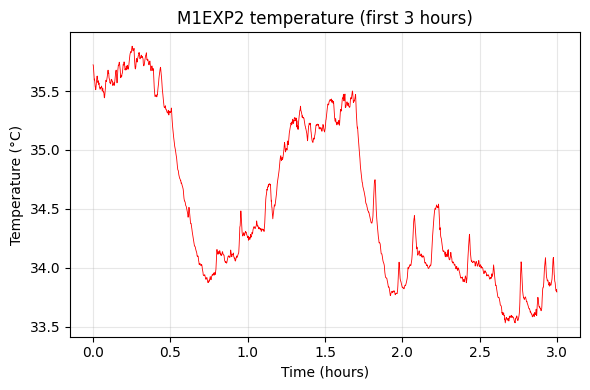

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

t_hours = np.arange(len(df_ex)) * 4/3600
ax.plot(t_hours[:2700], df_ex['temperature'].values[:2700],
        linewidth=0.6, color='red')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'M1EXP2 temperature (first 3 hours)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

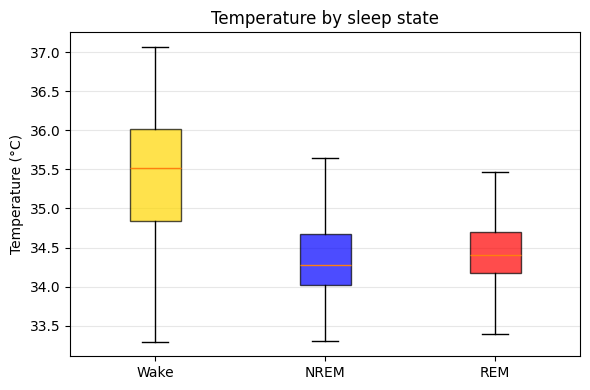

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

state_order = ['w', 'n', 'r']
state_names = ['Wake', 'NREM', 'REM']
data_by_state = [
    df_ex.loc[df_ex['state'] == s, 'temperature'].values
    for s in state_order
]

bp = ax.boxplot(data_by_state, labels=state_names,
                patch_artist=True, showfliers=False)

colors = ['gold', 'blue', 'red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature by sleep state')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Cortical temperature by sleep state (all nine EXP2 mice combined)

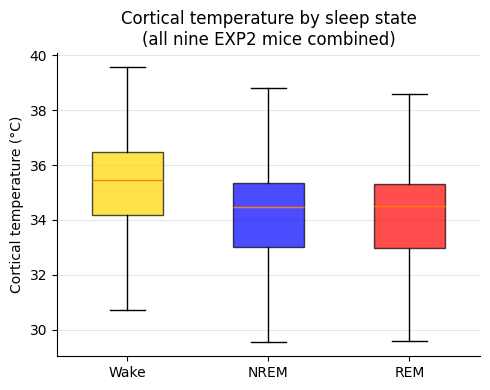

In [12]:
import os
os.makedirs('figures', exist_ok=True)

all_temp_combined = pd.concat(mouse_dfs_temp.values(), ignore_index=True)

state_order = ['w', 'n', 'r']
state_names = ['Wake', 'NREM', 'REM']
data_by_state = [
    all_temp_combined.loc[all_temp_combined['state'] == s, 'temperature'].values
    for s in state_order
]

fig, ax = plt.subplots(figsize=(5, 4))

bp = ax.boxplot(data_by_state, labels=state_names, patch_artist=True, showfliers=False, widths=0.5)

colors = ['gold', 'blue', 'red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Cortical temperature (°C)')
ax.set_title('Cortical temperature by sleep state\n(all nine EXP2 mice combined)')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/temp_by_state_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
all_temp_combined.groupby('state')['temperature'].agg(['mean', 'std', 'median']).round(2).rename(index={'w': 'Wake', 'n': 'NREM', 'r': 'REM'})

,mean,std,median
state,,,
NREM,33.459999,5.14,34.490002
REM,33.459999,5.19,34.509998
Wake,34.240002,6.17,35.439999


In [14]:
FEATURES_NO_TEMP = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma','eeg_variance', 'emg_variance', 'delta2_delta1_ratio']

FEATURES_WITH_TEMP = FEATURES_NO_TEMP + ['temperature']
LABEL = 'state'

## RF without temperature (EXP2 baseline)

Same 8 features as EXP1, baseline performance on EXP2 before adding temperature.

In [15]:
mouse_ids = list(mouse_dfs.keys())

In [16]:
results_no_temp = []
all_y_true_no_temp = []
all_y_pred_no_temp = []

for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]
    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES_NO_TEMP].values
    y_train = train_df[LABEL].values
    X_test = test_df[FEATURES_NO_TEMP].values
    y_test = test_df[LABEL].values

    clf = RandomForestClassifier(
        n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=7
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    results_no_temp.append({'mouse': test_mouse, 'balanced_accuracy':bal_acc})
    all_y_true_no_temp.extend(y_test)
    all_y_pred_no_temp.extend(y_pred)

    print(f'{test_mouse}: balanced accuracy = {bal_acc:.3f}')

results_no_temp_df = pd.DataFrame(results_no_temp)

M1EXP2: balanced accuracy = 0.834
M2EXP2: balanced accuracy = 0.830
M3EXP2: balanced accuracy = 0.792
M4EXP2: balanced accuracy = 0.906
M5EXP2: balanced accuracy = 0.706
M6EXP2: balanced accuracy = 0.656
M7EXP2: balanced accuracy = 0.881
M8EXP2: balanced accuracy = 0.758
M9EXP2: balanced accuracy = 0.924


In [17]:
print(f'\nMean balanced accuracy: {results_no_temp_df["balanced_accuracy"].mean():.3f} '
f'+/- {results_no_temp_df["balanced_accuracy"].std():.3f}')


Mean balanced accuracy: 0.810 +/- 0.091


In [18]:
kappa = cohen_kappa_score(all_y_true_no_temp, all_y_pred_no_temp)
mcc   = matthews_corrcoef(all_y_true_no_temp, all_y_pred_no_temp)
print(f"Cohen's kappa: {kappa:.4f}    MCC: {mcc:.4f}")

Cohen's kappa: 0.8516    MCC: 0.8520


## RF with temperature

Adds cortical temperature as a 9th feature. Temperature looks like it drops during sleep so it could help separate Wake from sleep states.

In [19]:
results_with_temp = []
all_y_true_with_temp = []
all_y_pred_with_temp = []

for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]
    train_df = pd.concat([mouse_dfs_temp[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs_temp[test_mouse]

    X_train = train_df[FEATURES_WITH_TEMP].values
    y_train = train_df[LABEL].values
    X_test  = test_df[FEATURES_WITH_TEMP].values
    y_test  = test_df[LABEL].values

    clf = RandomForestClassifier(
        n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=7
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    results_with_temp.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})
    all_y_true_with_temp.extend(y_test)
    all_y_pred_with_temp.extend(y_pred)

    print(f'{test_mouse}: balanced accuracy = {bal_acc:.3f}')

results_with_temp_df = pd.DataFrame(results_with_temp)

M1EXP2: balanced accuracy = 0.832
M2EXP2: balanced accuracy = 0.826
M3EXP2: balanced accuracy = 0.825
M4EXP2: balanced accuracy = 0.905
M5EXP2: balanced accuracy = 0.725
M6EXP2: balanced accuracy = 0.608
M7EXP2: balanced accuracy = 0.858
M8EXP2: balanced accuracy = 0.731
M9EXP2: balanced accuracy = 0.830


In [20]:
print(f'\nMean balanced accuracy: {results_with_temp_df["balanced_accuracy"].mean():.3f} '
f'+/- {results_with_temp_df["balanced_accuracy"].std():.3f}')


Mean balanced accuracy: 0.793 +/- 0.090


## Comparison

In [21]:
kappa = cohen_kappa_score(all_y_true_with_temp, all_y_pred_with_temp)
mcc   = matthews_corrcoef(all_y_true_with_temp, all_y_pred_with_temp)
print(f"Cohen's kappa: {kappa:.4f}  MCC: {mcc:.4f}")

Cohen's kappa: 0.8200  MCC: 0.8203


In [22]:
metrics = {}
for label, y_true, y_pred in [
    ('RF (no temp)', all_y_true_no_temp,   all_y_pred_no_temp),
    ('RF + temp',all_y_true_with_temp,  all_y_pred_with_temp)]:
    metrics[label] = {
        'Balanced accuracy': balanced_accuracy_score(y_true, y_pred),
        "Cohen's kappa":cohen_kappa_score(y_true, y_pred),
        'MCC':matthews_corrcoef(y_true, y_pred),
    }   

print(f'{"Metric":25s} {"RF (no temp)":>14s} {"RF + temp":>12s} {"Change":>8s}')
for metric in metrics['RF (no temp)']:
    v1 = metrics['RF (no temp)'][metric]
    v2 = metrics['RF + temp'][metric]
    print(f'{metric:25s} {v1:14.4f} {v2:12.4f} {v2-v1:+8.4f}')

Metric                      RF (no temp)    RF + temp   Change
Balanced accuracy                 0.8087       0.7911  -0.0176
Cohen's kappa                     0.8516       0.8200  -0.0316
MCC                               0.8520       0.8203  -0.0317


In [23]:
print(f'\nPer-mouse balanced accuracy:')
print(f'RF (no temp): {results_no_temp_df["balanced_accuracy"].mean():.3f} +/- {results_no_temp_df["balanced_accuracy"].std():.3f}')
print(f'RF + temp: {results_with_temp_df["balanced_accuracy"].mean():.3f} +/- {results_with_temp_df["balanced_accuracy"].std():.3f}')


Per-mouse balanced accuracy:
RF (no temp): 0.810 +/- 0.091
RF + temp: 0.793 +/- 0.090


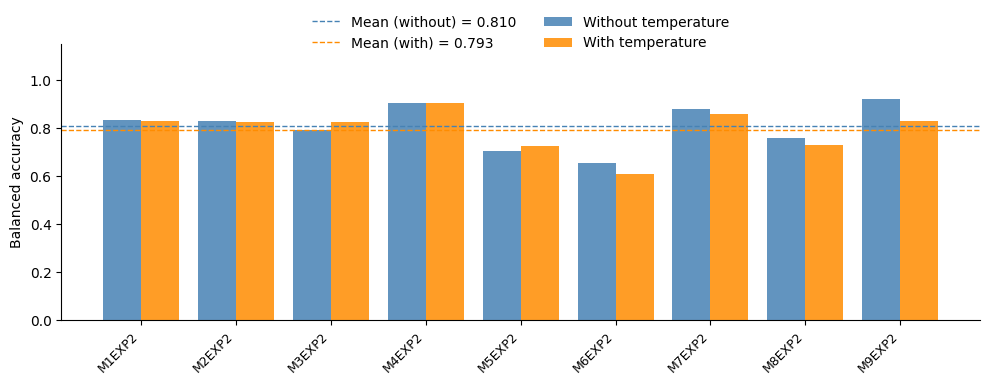

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(mouse_ids))
width = 0.4
ax.bar(x - width/2, results_no_temp_df['balanced_accuracy'], width,
       label='Without temperature', color='steelblue', alpha=0.85)
ax.bar(x + width/2, results_with_temp_df['balanced_accuracy'], width,
       label='With temperature', color='darkorange', alpha=0.85)
ax.axhline(results_no_temp_df['balanced_accuracy'].mean(),
           color='steelblue', linestyle='--', linewidth=1,
           label=f'Mean (without) = {results_no_temp_df["balanced_accuracy"].mean():.3f}')
ax.axhline(results_with_temp_df['balanced_accuracy'].mean(),
           color='darkorange', linestyle='--', linewidth=1,
           label=f'Mean (with) = {results_with_temp_df["balanced_accuracy"].mean():.3f}')
ax.set_xticks(x)
ax.set_xticklabels(mouse_ids, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Balanced accuracy')
ax.set_ylim(0, 1.15)
ax.legend(frameon=False, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.15))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/temp_comparison_grouped.png', dpi=300, bbox_inches='tight')
plt.show()

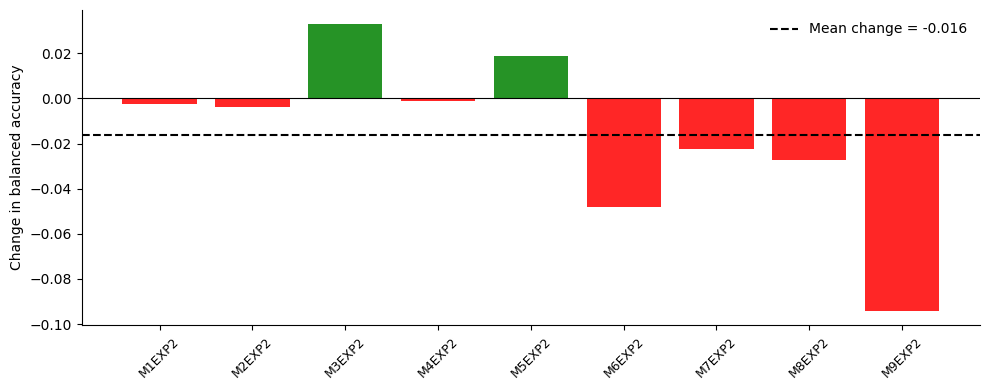

In [37]:
delta = (results_with_temp_df['balanced_accuracy'].values - results_no_temp_df['balanced_accuracy'].values)

fig, ax = plt.subplots(figsize=(10, 4))

bar_colors = ['green' if d > 0 else 'red' for d in delta]
ax.bar(mouse_ids, delta, color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(delta.mean(), color='black', linestyle='--',
           label=f'Mean change = {delta.mean():+.3f}')
ax.set_ylabel('Change in balanced accuracy')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/temp_comparison_delta.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
labels = ['w', 'n', 'r']
label_names = ['Wake', 'NREM', 'REM']

print('RF without temperature:')
print(classification_report(all_y_true_no_temp, all_y_pred_no_temp, labels=labels, target_names=label_names))

print('RF with temperature:')
print(classification_report(all_y_true_with_temp, all_y_pred_with_temp, labels=labels, target_names=label_names))

RF without temperature:
              precision    recall  f1-score   support

        Wake       0.93      0.95      0.94    429339
        NREM       0.93      0.94      0.93    301893
         REM       0.72      0.54      0.62     46368

    accuracy                           0.92    777600
   macro avg       0.86      0.81      0.83    777600
weighted avg       0.92      0.92      0.92    777600

RF with temperature:
              precision    recall  f1-score   support

        Wake       0.92      0.94      0.93    429339
        NREM       0.92      0.92      0.92    301893
         REM       0.64      0.52      0.57     46368

    accuracy                           0.90    777600
   macro avg       0.82      0.79      0.81    777600
weighted avg       0.90      0.90      0.90    777600



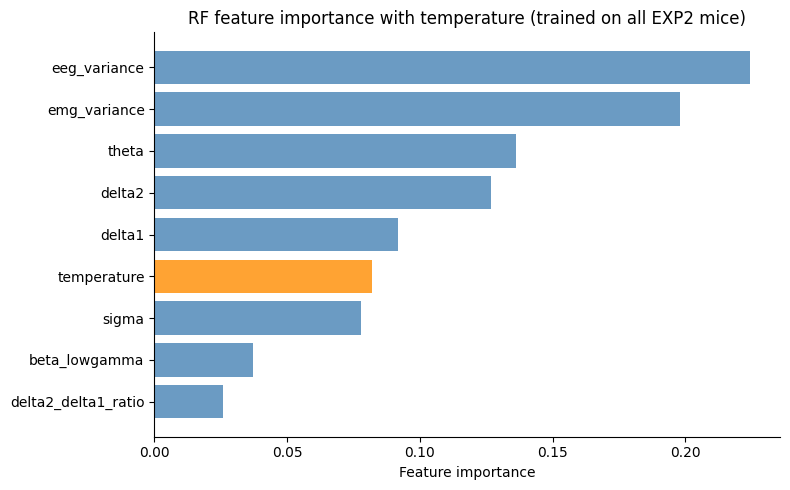

In [42]:
# checking where temperature ranks for feature importance
all_df = pd.concat(mouse_dfs_temp.values(), ignore_index=True)
clf_full = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=7
)
clf_full.fit(all_df[FEATURES_WITH_TEMP], all_df[LABEL])

importance_df = pd.DataFrame({
    'feature': FEATURES_WITH_TEMP,
    'importance': clf_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colours = ['darkorange' if f == 'temperature' else 'steelblue' for f in importance_df['feature']]
ax.barh(importance_df['feature'], importance_df['importance'], color=colours, alpha=0.8)
ax.set_xlabel('Feature importance')
ax.set_title('RF feature importance with temperature (trained on all EXP2 mice)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/feature_importance_temp.png', dpi=300, bbox_inches='tight')
plt.show()

Adding cortical temperature as a feature didn't improve classification, it made performance worse overall (kappa score went from 0.852 to 0.820, and balanced accuracy from 0.809 to 0.791).

There seems to be a difference for the temperatures within each sleep state, Wake epochs average around 35.4°C compared to 34.4°C for NREM and REM. The problem seems to be the data being noisy and heavily overlapping across states.

The more important factor is EXP2 files being sleep deprivation recordings, where mice are kept awake for 6 hours before being allowed to recover. Sleep deprivation disrupts circadian rhythms and cortical temperature in mice follows a strong circadian pattern so it could be the main factor to why it decreases performance (will do further research)

Because of that temperature seems to become less predictable and less consistent across the mice, making it harder for the model with only 8 training animals per fold.

The feature importance plot supports shows temperature ranks low relative to the EEG frequency bands.

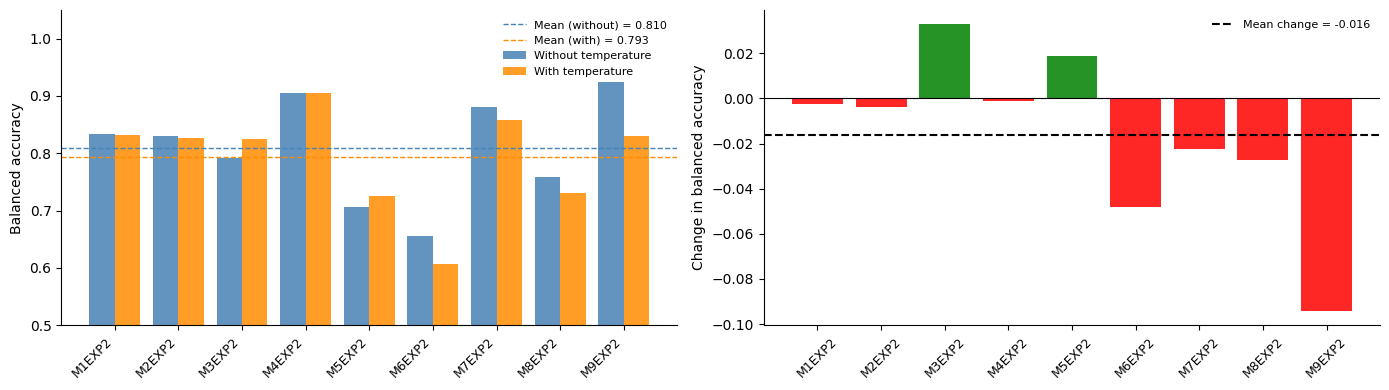

In [ ]:
# combined comparison figure of above plots
delta = (results_with_temp_df['balanced_accuracy'].values
         - results_no_temp_df['balanced_accuracy'].values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(mouse_ids))
width = 0.4
ax1.bar(x - width/2, results_no_temp_df['balanced_accuracy'], width,
        label='Without temperature', color='steelblue', alpha=0.85)
ax1.bar(x + width/2, results_with_temp_df['balanced_accuracy'], width,
        label='With temperature', color='darkorange', alpha=0.85)
ax1.axhline(results_no_temp_df['balanced_accuracy'].mean(),
            color='steelblue', linestyle='--', linewidth=1,
            label=f'Mean (without) = {results_no_temp_df["balanced_accuracy"].mean():.3f}')
ax1.axhline(results_with_temp_df['balanced_accuracy'].mean(),
            color='darkorange', linestyle='--', linewidth=1,
            label=f'Mean (with) = {results_with_temp_df["balanced_accuracy"].mean():.3f}')
ax1.set_xticks(x)
ax1.set_xticklabels(mouse_ids, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Balanced accuracy')
ax1.set_ylim(0.5, 1.05)
ax1.legend(frameon=False, fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right panel: per-mouse change (delta) ---
bar_colors = ['green' if d > 0 else 'red' for d in delta]
ax2.bar(mouse_ids, delta, color=bar_colors, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(delta.mean(), color='black', linestyle='--',
            label=f'Mean change = {delta.mean():+.3f}')
ax2.set_ylabel('Change in balanced accuracy')
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.legend(frameon=False, fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/temp_comparison_combined.png', dpi=300, bbox_inches='tight')
plt.show()